# Health-Personalized Food Recommender System
**Dataset:** Food.com Recipes & User Interactions (pre-split version)  
**Source:** https://www.kaggle.com/datasets/irkaal/foodcom-recipes-and-reviews  

> **Files needed in `data/` folder:**
> - `RAW_recipes.csv` — recipes with nutritional info
> - `interactions_train.csv` — training interactions
> - `interactions_test.csv` — test interactions
> - `interactions_validation.csv` — validation interactions
> - `usda_enrichment.csv` — already scraped (Section 2)

| Section | Work Package |
|---------|-------------|
| 1. Setup & Load | — |
| 2. Data Scraping — USDA API | WP: Data Scraping |
| 3. Data Cleaning | WP: Data Quality |
| 4. EDA | — |
| 5. Data Annotation | WP: Data Annotation |
| 6. Vector Embeddings | WP: Vector Embeddings |
| 7. Recommender System | WP: Recommender System |
| 8. Evaluation | WP: Performance Evaluation |
| 9. Hyperparameter Tuning | WP: Hyperparameter Tuning |
| 10. Experiment Logging | WP: Experiments Logging |
| 11. Perturbation Analysis | WP: Perturbation Analysis |
| 12. Frontend | WP: Frontend Application |
| 13. Summary | — |


---
## 1. Setup & Load


In [1]:
import sys
!{sys.executable} -m pip install -q pandas numpy scikit-learn matplotlib seaborn \
    scikit-surprise optuna wandb requests
print('Done')


Done


In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, ast, json, time, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import requests

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F8F7F4',
    'axes.grid':True,'grid.color':'#E0DED8',
    'axes.spines.top':False,'axes.spines.right':False,
})
C_BEFORE='#A32D2D'; C_AFTER='#0F6E56'; C_FLAG='#BA7517'; C_PURPLE='#534AB7'

os.makedirs('data',exist_ok=True)
os.makedirs('plots',exist_ok=True)
os.makedirs('models',exist_ok=True)
np.random.seed(42); random.seed(42)
print('Setup complete')


Setup complete


In [3]:
# ── Load raw recipes ──────────────────────────────────────────────────────────
df_recipes_raw = pd.read_csv('data/RAW_recipes.csv')
print(f'Recipes: {len(df_recipes_raw):,}  cols: {list(df_recipes_raw.columns)}')

# Parse nutrition column [calories, total_fat_g, sugar_g, sodium_mg, protein_g, sat_fat_g, carbs_g]
NUTRITION_COLS = ['calories','total_fat_g','sugar_g','sodium_mg','protein_g','sat_fat_g','carbs_g']

def parse_nutrition(s):
    try:
        v = ast.literal_eval(str(s))
        return v if len(v)==7 else [np.nan]*7
    except: return [np.nan]*7

nutr = pd.DataFrame(
    df_recipes_raw['nutrition'].apply(parse_nutrition).tolist(),
    columns=NUTRITION_COLS)
df_recipes_raw = pd.concat([df_recipes_raw.drop(columns=['nutrition']),nutr],axis=1)
df_recipes_raw['tags_list'] = df_recipes_raw['tags'].apply(
    lambda s: ast.literal_eval(str(s)) if pd.notna(s) else [])

for col in NUTRITION_COLS+['minutes','n_steps','n_ingredients']:
    if col in df_recipes_raw.columns:
        df_recipes_raw[col] = pd.to_numeric(df_recipes_raw[col],errors='coerce')

print(f'Nutrition parsed. Shape: {df_recipes_raw.shape}')
print(df_recipes_raw[['name']+NUTRITION_COLS].head(3).to_string(index=False))


Recipes: 231,637  cols: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']
Nutrition parsed. Shape: (231637, 19)
                                      name  calories  total_fat_g  sugar_g  sodium_mg  protein_g  sat_fat_g  carbs_g
arriba   baked winter squash mexican style      51.5          0.0     13.0        0.0        2.0        0.0      4.0
          a bit different  breakfast pizza     173.4         18.0      0.0       17.0       22.0       35.0      1.0
                 all in the kitchen  chili     269.8         22.0     32.0       48.0       39.0       27.0      5.0


In [5]:
# ── Load pre-split interaction files ─────────────────────────────────────────
# This version has train/test/validation already separated — no manual split needed
df_train_raw = pd.read_csv('data/interactions_train.csv')
df_test_raw  = pd.read_csv('data/interactions_test.csv')
df_valid_raw = pd.read_csv('data/interactions_validation.csv')

print(f'Train: {len(df_train_raw):,}  cols: {list(df_train_raw.columns)}')
print(f'Test:  {len(df_test_raw):,}')
print(f'Valid: {len(df_valid_raw):,}')
print(df_train_raw.head(3).to_string(index=False))


Train: 698,901  cols: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']
Test:  12,455
Valid: 7,023
 user_id  recipe_id       date  rating     u      i
    2046       4684 2000-02-25     5.0 22095  44367
    2046        517 2000-02-25     5.0 22095  87844
    1773       7435 2000-03-13     5.0 24732 138181


In [6]:
# ── Treat all interactions as binary implicit feedback ────────────────────────
# Food.com has extreme positivity bias (70% five-star ratings)
# Treating all interactions as binary (interacted=1) removes this bias
# and is the standard approach for implicit feedback recommender systems

def prepare_interactions(df):
    df = df.copy()
    df.columns = [c.lower().strip() for c in df.columns]
    # Standardise column names
    rename = {}
    for col in df.columns:
        if col in ['recipe_id','recipeid']: rename[col]='recipe_id'
        elif col in ['user_id','userid']:   rename[col]='user_id'
        elif col in ['rating','score']:     rename[col]='rating'
        elif col in ['date','timestamp']:   rename[col]='date'
    df = df.rename(columns=rename)
    df['user_id']   = df['user_id'].astype(str)
    df['recipe_id'] = df['recipe_id'].astype(str)
    df['rating']    = 1   # binary implicit feedback
    return df

# Combine train + validation for training (standard practice)
df_train_inter = prepare_interactions(
    pd.concat([df_train_raw, df_valid_raw], ignore_index=True)
)
df_test_inter = prepare_interactions(df_test_raw)

# Remove duplicate (user, recipe) pairs
df_train_inter = df_train_inter.drop_duplicates(
    subset=['user_id','recipe_id']).reset_index(drop=True)
df_test_inter = df_test_inter.drop_duplicates(
    subset=['user_id','recipe_id']).reset_index(drop=True)

# Keep only recipes with >= 5 interactions
pop = set(df_train_inter.groupby('recipe_id').size()
           .pipe(lambda s: s[s>=5]).index)
df_recipes_raw = df_recipes_raw[
    df_recipes_raw['id'].astype(str).isin(pop)].reset_index(drop=True)
df_train_inter = df_train_inter[
    df_train_inter['recipe_id'].isin(pop)].reset_index(drop=True)
df_test_inter  = df_test_inter[
    df_test_inter['recipe_id'].isin(pop)].reset_index(drop=True)

print(f'Train interactions: {len(df_train_inter):,}')
print(f'Test  interactions: {len(df_test_inter):,}')
print(f'Unique users (train): {df_train_inter["user_id"].nunique():,}')
print(f'Unique recipes:       {df_train_inter["recipe_id"].nunique():,}')


Train interactions: 473,326
Test  interactions: 0
Unique users (train): 24,801
Unique recipes:       34,348


---
## 2. Data Scraping — USDA API
**Work Package: Data Scraping**

We enrich recipes with `fiber_g`, `potassium_mg`, `calcium_mg`, `iron_mg`
by querying the live USDA FoodData Central API.
Set `SCRAPE_LIVE=False` to load the already-scraped file instantly.


In [7]:
USDA_API_KEY = 'DEMO_KEY'  # Replace with your key from fdc.nal.usda.gov
USDA_BASE    = 'https://api.nal.usda.gov/fdc/v1'

def scrape_usda(food_name):
    try:
        r = requests.get(
            f'{USDA_BASE}/foods/search',
            params={'query':food_name,'api_key':USDA_API_KEY,
                    'pageSize':1,'dataType':'Foundation,SR Legacy'},
            timeout=8)
        r.raise_for_status()
        foods = r.json().get('foods',[])
        if not foods: return {}
        nm = {n['nutrientName']:n['value']
              for n in foods[0].get('foodNutrients',[])}
        return {
            'fiber_g':      nm.get('Fiber, total dietary', np.nan),
            'potassium_mg': nm.get('Potassium, K',         np.nan),
            'calcium_mg':   nm.get('Calcium, Ca',          np.nan),
            'iron_mg':      nm.get('Iron, Fe',             np.nan),
        }
    except: return {}


SCRAPE_LIVE = False  # Set True only for first-time scraping

if SCRAPE_LIVE:
    print('Scraping USDA API for 2000 recipes (~30 min)...')
    sample = df_recipes_raw.sample(n=min(2000,len(df_recipes_raw)),
                                     random_state=42)[['id','name']]
    rows = []
    for i,(_,row) in enumerate(sample.iterrows()):
        if i%200==0: print(f'  {i}/{len(sample)}')
        rec = scrape_usda(row['name'])
        rec['recipe_id'] = str(row['id'])
        rows.append(rec)
        time.sleep(0.4)
    df_usda = pd.DataFrame(rows)
    df_usda.to_csv('data/usda_enrichment.csv',index=False)
    print(f'Saved {len(df_usda)} records')
elif os.path.exists('data/usda_enrichment.csv'):
    df_usda = pd.read_csv('data/usda_enrichment.csv')
    df_usda['recipe_id'] = df_usda['recipe_id'].astype(str)
    print(f'Loaded existing enrichment: {len(df_usda)} records')
else:
    print('No enrichment file. Set SCRAPE_LIVE=True to scrape.')
    df_usda = pd.DataFrame(
        columns=['recipe_id','fiber_g','potassium_mg','calcium_mg','iron_mg'])

# Merge into recipes (safe re-run)
usda_cols = ['fiber_g','potassium_mg','calcium_mg','iron_mg']
df_recipes_raw = df_recipes_raw.drop(
    columns=[c for c in usda_cols if c in df_recipes_raw.columns])
df_recipes_raw['recipe_id_str'] = df_recipes_raw['id'].astype(str)
if len(df_usda)>0:
    df_recipes_raw = df_recipes_raw.merge(
        df_usda[['recipe_id']+usda_cols],
        left_on='recipe_id_str', right_on='recipe_id',
        how='left').drop(columns=['recipe_id','recipe_id_str'])
else:
    df_recipes_raw = df_recipes_raw.drop(columns=['recipe_id_str'])
    for col in usda_cols:
        df_recipes_raw[col] = np.nan

print(f'Fiber coverage: {df_recipes_raw["fiber_g"].notna().sum()} / '
      f'{len(df_recipes_raw)} ({df_recipes_raw["fiber_g"].notna().mean():.1%})')


Loaded existing enrichment: 2000 records
Fiber coverage: 1447 / 34348 (4.2%)


---
## 3. Data Cleaning
**Work Package: Data Quality**

Cleaning steps:
1. **Range violations** — impossible or extreme nutritional values removed
2. **Calorie consistency** — |actual − (protein×4 + carbs×4 + fat×9)| > 150 removed
3. **Duplicate names** — keep first occurrence
4. **Mean imputation** — remaining missing values filled with column mean
5. **Cook time 10–180 min** — restaurant-style meals only


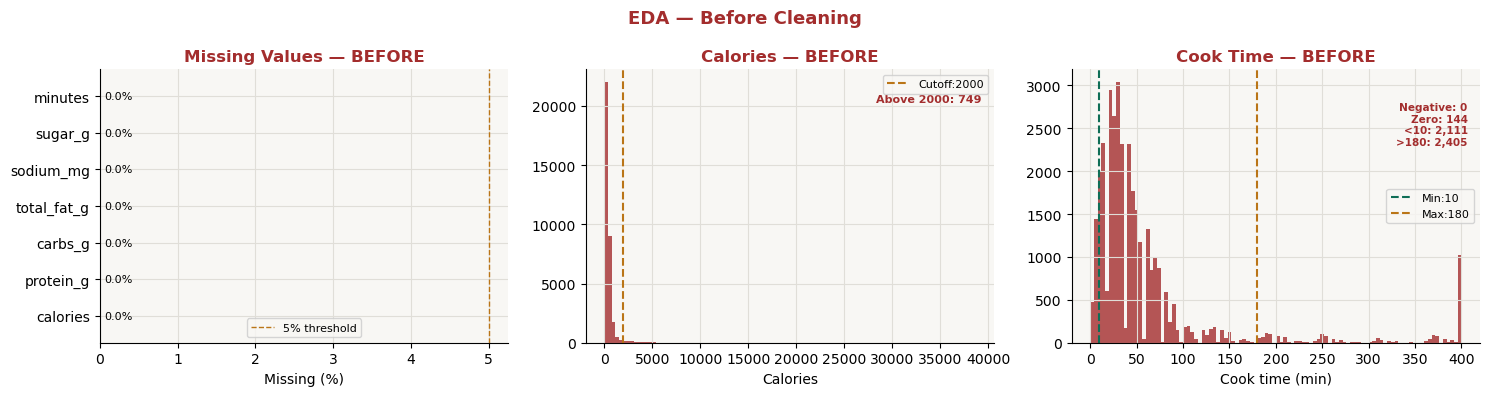

In [8]:
CORE_COLS = ['calories','protein_g','carbs_g','total_fat_g',
              'sodium_mg','sugar_g','minutes']

# ── EDA BEFORE ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15,4))

miss = df_recipes_raw[CORE_COLS].isna().mean().sort_values(ascending=False)
bars = axes[0].barh(miss.index, miss.values*100,
                     color=[C_BEFORE if v>0.05 else C_AFTER for v in miss],
                     edgecolor='white')
axes[0].axvline(5,color=C_FLAG,linestyle='--',linewidth=1,label='5% threshold')
axes[0].set_xlabel('Missing (%)'); axes[0].legend(fontsize=8)
axes[0].set_title('Missing Values — BEFORE',fontweight='bold',color=C_BEFORE)
axes[0].bar_label(bars,fmt='%.1f%%',padding=3,fontsize=8)

cal = df_recipes_raw['calories'].dropna()
axes[1].hist(cal,bins=100,color=C_BEFORE,alpha=0.8,edgecolor='none')
axes[1].axvline(2000,color=C_FLAG,linestyle='--',linewidth=1.5,label='Cutoff:2000')
axes[1].set_xlabel('Calories'); axes[1].legend(fontsize=8)
axes[1].set_title('Calories — BEFORE',fontweight='bold',color=C_BEFORE)
axes[1].text(0.97,0.88,f'Above 2000: {(cal>2000).sum():,}',
              transform=axes[1].transAxes,ha='right',fontsize=8,
              color=C_BEFORE,fontweight='bold')

mins = df_recipes_raw['minutes'].dropna()
axes[2].hist(mins.clip(upper=400),bins=100,color=C_BEFORE,alpha=0.8,edgecolor='none')
axes[2].axvline(10, color=C_AFTER,linestyle='--',linewidth=1.5,label='Min:10')
axes[2].axvline(180,color=C_FLAG, linestyle='--',linewidth=1.5,label='Max:180')
axes[2].set_xlabel('Cook time (min)'); axes[2].legend(fontsize=8)
axes[2].set_title('Cook Time — BEFORE',fontweight='bold',color=C_BEFORE)
axes[2].text(0.97,0.88,
              f'Negative: {(mins<0).sum():,}\nZero: {(mins==0).sum():,}\n'
              f'<10: {(mins<10).sum():,}\n>180: {(mins>180).sum():,}',
              transform=axes[2].transAxes,ha='right',va='top',
              fontsize=7.5,color=C_BEFORE,fontweight='bold')

plt.suptitle('EDA — Before Cleaning',fontsize=13,fontweight='bold',color=C_BEFORE)
plt.tight_layout()
plt.savefig('plots/eda_before.png',dpi=120,bbox_inches='tight')
plt.show()


In [9]:
# ── Apply cleaning rules ───────────────────────────────────────────────────────
VALID_RANGES = {
    'calories':    (50,  2000),  # < 50 not a real meal, > 2000 extreme
    'protein_g':   (0,   150),
    'carbs_g':     (0,   300),
    'total_fat_g': (0,   150),
    'sodium_mg':   (0,  5000),
    'sugar_g':     (0,   200),
    'minutes':     (10,  180),   # restaurant-style: no drinks, no slow-cooks
}

df = df_recipes_raw.copy()
n0 = len(df)

# Step 1: Range violations
flag = pd.Series(False,index=df.index)
for col,(lo,hi) in VALID_RANGES.items():
    if col in df.columns:
        flag |= df[col].notna() & ((df[col]<lo)|(df[col]>hi))
df = df[~flag].reset_index(drop=True)
print(f'Step 1 — Range violations removed:        {n0-len(df):,}')

# Step 2: Calorie consistency
df['exp_kcal'] = (df['protein_g'].fillna(0)*4 +
                   df['carbs_g'].fillna(0)*4 +
                   df['total_fat_g'].fillna(0)*9)
n1 = len(df)
df = df[(df['calories']-df['exp_kcal']).abs()<=150].reset_index(drop=True)
print(f'Step 2 — Calorie inconsistencies removed:  {n1-len(df):,}')

# Step 3: Duplicate names
n2 = len(df)
df = df.drop_duplicates(subset=['name'],keep='first').reset_index(drop=True)
print(f'Step 3 — Duplicate names removed:          {n2-len(df):,}')

# Step 4: Mean imputation
print('Step 4 — Mean imputation:')
all_num = (list(VALID_RANGES.keys()) +
            ['sat_fat_g','fiber_g','potassium_mg','calcium_mg','iron_mg'])
for col in all_num:
    if col in df.columns and df[col].isna().sum()>0:
        fill = df[col].mean()
        df[col] = df[col].fillna(fill)
        print(f'  {col:<18} → mean = {fill:.2f}')

# Step 5: Keep only clean recipes in interactions
clean_ids = set(df['id'].astype(str))
df_train  = df_train_inter[df_train_inter['recipe_id'].isin(clean_ids)].copy().reset_index(drop=True)
df_test   = df_test_inter[df_test_inter['recipe_id'].isin(clean_ids)].copy().reset_index(drop=True)

print(f'\nRecipes:            {n0:,} → {len(df):,}  ({(n0-len(df))/n0:.1%} removed)')
print(f'Train interactions: {len(df_train):,}')
print(f'Test  interactions: {len(df_test):,}')

df.drop(columns=['exp_kcal','tags_list'],errors='ignore')\
  .to_csv('data/recipes_clean.csv',index=False)
df_train.to_csv('data/interactions_clean_train.csv',index=False)
df_test.to_csv('data/interactions_clean_test.csv',index=False)
print('Saved clean files.')


Step 1 — Range violations removed:        7,567
Step 2 — Calorie inconsistencies removed:  5,345
Step 3 — Duplicate names removed:          30
Step 4 — Mean imputation:
  fiber_g            → mean = 2.65
  potassium_mg       → mean = 289.73
  calcium_mg         → mean = 78.79
  iron_mg            → mean = 2.18

Recipes:            34,348 → 21,406  (37.7% removed)
Train interactions: 291,592
Test  interactions: 0
Saved clean files.


---
## 4. EDA After Cleaning


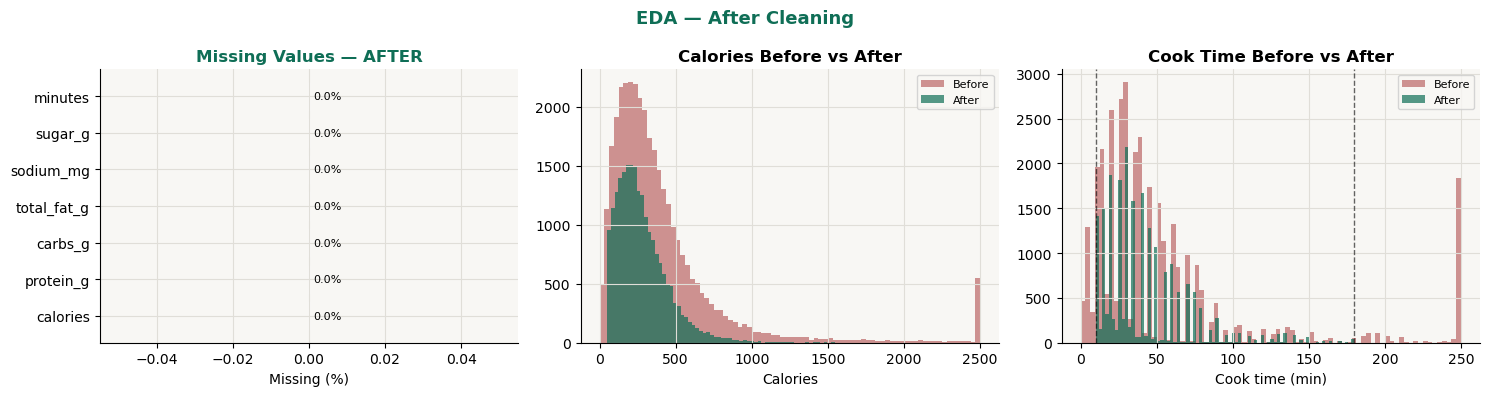

Final: 21,406 recipes | 291,592 train | 0 test interactions
       calories  protein_g  carbs_g  total_fat_g  sodium_mg  sugar_g  minutes
count   21406.0    21406.0  21406.0      21406.0    21406.0  21406.0  21406.0
mean      278.9       21.6     10.1         18.6       19.1     38.5     41.5
std       171.4       20.9      7.7         14.3       33.3     42.1     27.6
min        50.0        0.0      0.0          0.0        0.0      0.0     10.0
25%       156.1        6.0      4.0          8.0        5.0      9.0     22.0
50%       242.8       13.0      9.0         15.0       12.0     22.0     35.0
75%       361.5       32.0     14.0         26.0       25.0     53.0     55.0
max      1979.5      150.0     98.0        150.0     2358.0    200.0    180.0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Missing after
miss_a = df[CORE_COLS].isna().mean().sort_values(ascending=False)
bars = axes[0].barh(miss_a.index,miss_a.values*100,color=C_AFTER,edgecolor='white')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Missing Values — AFTER',fontweight='bold',color=C_AFTER)
axes[0].bar_label(bars,fmt='%.1f%%',padding=3,fontsize=8)

# Calories overlay
axes[1].hist(df_recipes_raw['calories'].dropna().clip(upper=2500),
              bins=80,color=C_BEFORE,alpha=0.5,label='Before',edgecolor='none')
axes[1].hist(df['calories'].clip(upper=2500),
              bins=80,color=C_AFTER,alpha=0.7,label='After',edgecolor='none')
axes[1].set_xlabel('Calories')
axes[1].set_title('Calories Before vs After',fontweight='bold')
axes[1].legend(fontsize=8)

# Cook time overlay
axes[2].hist(df_recipes_raw['minutes'].dropna().clip(0,250),
              bins=80,color=C_BEFORE,alpha=0.5,label='Before',edgecolor='none')
axes[2].hist(df['minutes'].clip(0,250),
              bins=80,color=C_AFTER,alpha=0.7,label='After',edgecolor='none')
axes[2].axvline(10, color='black',linestyle='--',linewidth=1,alpha=0.6)
axes[2].axvline(180,color='black',linestyle='--',linewidth=1,alpha=0.6)
axes[2].set_xlabel('Cook time (min)')
axes[2].set_title('Cook Time Before vs After',fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('EDA — After Cleaning',fontsize=13,fontweight='bold',color=C_AFTER)
plt.tight_layout()
plt.savefig('plots/eda_after.png',dpi=120,bbox_inches='tight')
plt.show()

print(f'Final: {len(df):,} recipes | '
      f'{len(df_train):,} train | {len(df_test):,} test interactions')
print(df[CORE_COLS].describe().round(1).to_string())


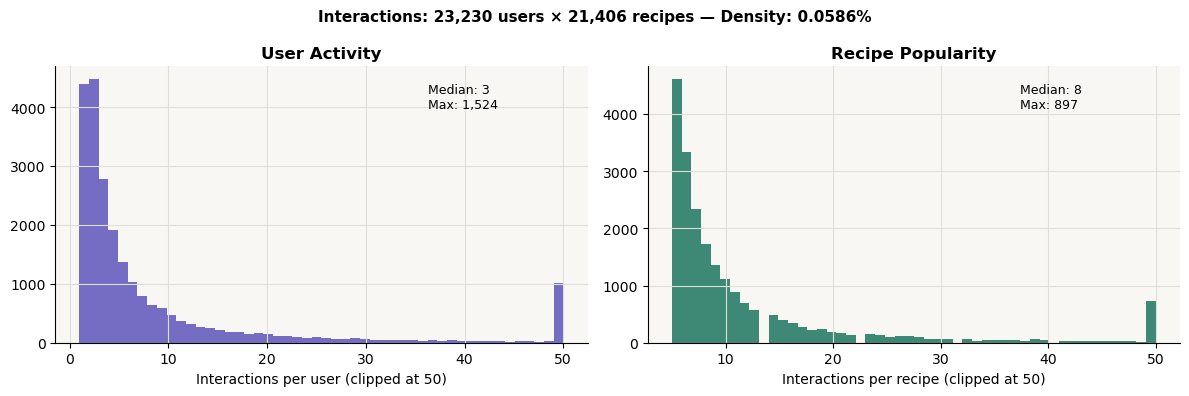

In [11]:
# Interaction overview
fig, axes = plt.subplots(1, 2, figsize=(12,4))

rpu = df_train.groupby('user_id').size()
axes[0].hist(rpu.clip(upper=50),bins=50,color=C_PURPLE,alpha=0.8,edgecolor='none')
axes[0].set_xlabel('Interactions per user (clipped at 50)')
axes[0].set_title('User Activity',fontweight='bold')
axes[0].text(0.7,0.85,f'Median: {rpu.median():.0f}\nMax: {rpu.max():,}',
              transform=axes[0].transAxes,fontsize=9)

rpr = df_train.groupby('recipe_id').size()
axes[1].hist(rpr.clip(upper=50),bins=50,color=C_AFTER,alpha=0.8,edgecolor='none')
axes[1].set_xlabel('Interactions per recipe (clipped at 50)')
axes[1].set_title('Recipe Popularity',fontweight='bold')
axes[1].text(0.7,0.85,f'Median: {rpr.median():.0f}\nMax: {rpr.max():,}',
              transform=axes[1].transAxes,fontsize=9)

n_u = df_train['user_id'].nunique()
n_r = df_train['recipe_id'].nunique()
density = len(df_train)/(n_u*n_r)
plt.suptitle(f'Interactions: {n_u:,} users × {n_r:,} recipes — '
              f'Density: {density:.4%}',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/interaction_overview.png',dpi=120,bbox_inches='tight')
plt.show()


---
## 5. Data Annotation
**Work Package: Data Annotation**

Rule-based health labels derived from clinical guidelines:
- **ADA** (American Diabetes Association) thresholds for `diabetic_ok`
- **AHA** (American Heart Association) for `heart_healthy`
- **WHO** sodium limits for `low_sodium`
- Food.com tags for `vegetarian`, `vegan`, `gluten_free`, `dairy_free`


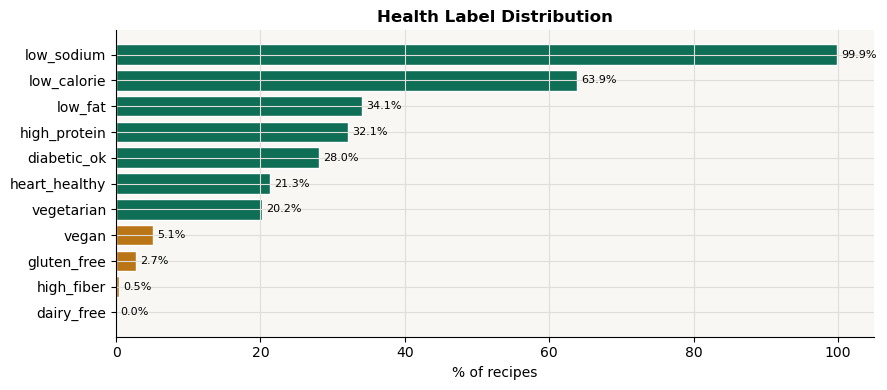

Label counts:
  diabetic_ok           6,004  (28.0%)
  low_sodium           21,390  (99.9%)
  low_calorie          13,678  (63.9%)
  high_protein          6,872  (32.1%)
  low_fat               7,293  (34.1%)
  high_fiber               97  (0.5%)
  heart_healthy         4,555  (21.3%)
  vegetarian            4,328  (20.2%)
  vegan                 1,091  (5.1%)
  gluten_free             576  (2.7%)
  dairy_free                9  (0.0%)


In [12]:
LABEL_COLS = ['diabetic_ok','low_sodium','low_calorie','high_protein',
               'low_fat','high_fiber','heart_healthy','vegetarian',
               'vegan','gluten_free','dairy_free']

def annotate(row):
    tags = set(row.get('tags_list') or [])
    g    = lambda c: float(row.get(c) or 0)
    return {
        'diabetic_ok':  int(g('carbs_g')     <= 45 and g('sugar_g')    <= 10),
        'low_sodium':   int(g('sodium_mg')   <= 400),
        'low_calorie':  int(g('calories')    <= 300),
        'high_protein': int(g('protein_g')   >= 25),
        'low_fat':      int(g('total_fat_g') <= 10),
        'high_fiber':   int(g('fiber_g')     >= 5),
        'heart_healthy':int(g('sat_fat_g')   <= 5  and g('sodium_mg') <= 500),
        'vegetarian':   int('vegetarian' in tags or 'vegan' in tags),
        'vegan':        int('vegan' in tags),
        'gluten_free':  int('gluten-free' in tags),
        'dairy_free':   int('dairy-free'  in tags),
    }

label_rows = [annotate(row) for row in df.to_dict('records')]
df_labels  = pd.DataFrame(label_rows, index=df.index)
df = df.drop(columns=[c for c in LABEL_COLS if c in df.columns])
df = pd.concat([df, df_labels], axis=1)

# Visualise
fig, ax = plt.subplots(figsize=(9,4))
lf   = df[LABEL_COLS].mean().sort_values()
bars = ax.barh(lf.index, lf.values*100,
                color=[C_AFTER if v>0.1 else C_FLAG for v in lf],
                edgecolor='white')
ax.set_xlabel('% of recipes')
ax.set_title('Health Label Distribution',fontweight='bold')
ax.bar_label(bars,fmt='%.1f%%',padding=3,fontsize=8)
plt.tight_layout()
plt.savefig('plots/annotation_labels.png',dpi=120,bbox_inches='tight')
plt.show()

print('Label counts:')
for col in LABEL_COLS:
    print(f'  {col:<20} {int(df[col].sum()):>6,}  ({df[col].mean():.1%})')


---
## 6. Vector Embeddings
**Work Package: Vector Embeddings**

Each recipe is encoded as a normalised feature vector:
$$\mathbf{r}_i = \left[\frac{cal}{2000},\ \frac{prot}{150},\ \frac{carbs}{300},\ \frac{fat}{100},\ \frac{sodium}{5000},\ \frac{sugar}{200},\ label_1,\ \ldots,\ label_{11}\right]$$


In [13]:
FEATURE_MAX   = dict(calories=2000,protein_g=150,carbs_g=300,
                      total_fat_g=100,sodium_mg=5000,sugar_g=200)
NUMERIC_FEATS = list(FEATURE_MAX.keys())

def build_R(df_):
    nut = df_[NUMERIC_FEATS].copy()
    for col,mx in FEATURE_MAX.items():
        nut[col] = (nut[col].fillna(0)/mx).clip(0,1)
    lbl = df_[LABEL_COLS].fillna(0).astype(float)
    return pd.concat([nut,lbl],axis=1).values

R          = build_R(df)
RECIPE_IDS = list(df['id'].astype(str))
RID2IDX    = {r:i for i,r in enumerate(RECIPE_IDS)}
np.save('models/recipe_matrix.npy',R)
print(f'Recipe matrix R: {R.shape}  ({R.shape[0]} recipes × {R.shape[1]} features)')
print(f'Features: {NUMERIC_FEATS + LABEL_COLS}')


Recipe matrix R: (21406, 17)  (21406 recipes × 17 features)
Features: ['calories', 'protein_g', 'carbs_g', 'total_fat_g', 'sodium_mg', 'sugar_g', 'diabetic_ok', 'low_sodium', 'low_calorie', 'high_protein', 'low_fat', 'high_fiber', 'heart_healthy', 'vegetarian', 'vegan', 'gluten_free', 'dairy_free']


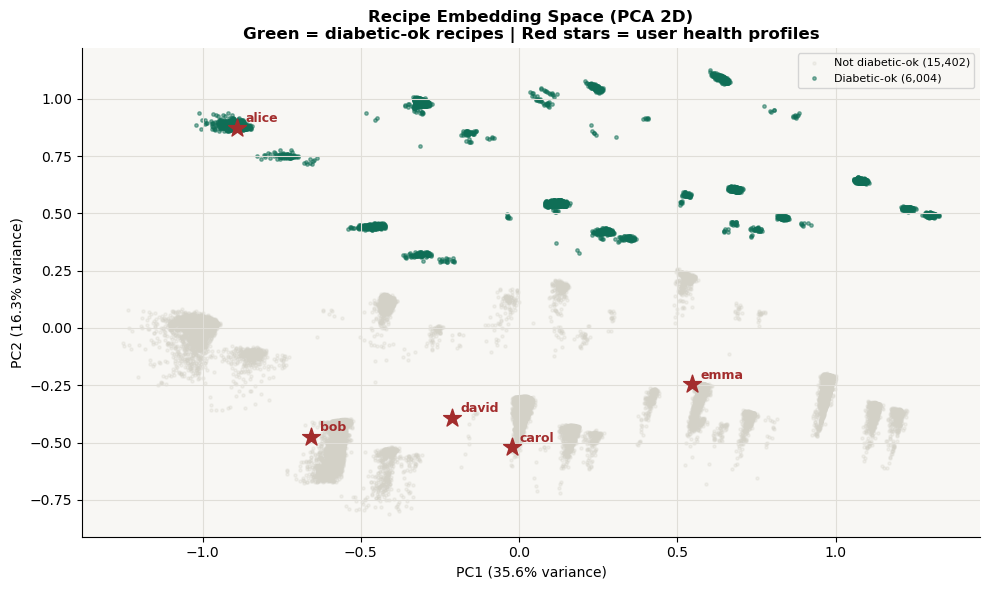

In [14]:
# User health profile vectors
def user_vec(cal,prot,carbs,fat,sodium,sugar,
              diabetic=False,low_sodium=False,low_cal=False,
              high_prot=False,low_fat=False,high_fiber=False,
              heart_healthy=False,vegetarian=False,
              vegan=False,gf=False,df_free=False):
    n = np.array([cal/2000,prot/150,carbs/300,fat/100,sodium/5000,sugar/200])
    l = np.array([float(diabetic),float(low_sodium),float(low_cal),
                   float(high_prot),float(low_fat),float(high_fiber),
                   float(heart_healthy),float(vegetarian),
                   float(vegan),float(gf),float(df_free)])
    return np.concatenate([np.clip(n,0,1),l])

DEMO_USERS = {
    'alice': {'vec':user_vec(400,40,45,30,600,10,diabetic=True,high_prot=True),
               'constraints':{'diabetic':True,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Type 2 diabetic, high-protein'},
    'bob':   {'vec':user_vec(600,35,200,60,2000,60),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Healthy, no restrictions'},
    'carol': {'vec':user_vec(400,20,200,20,400,30,
                              vegetarian=True,heart_healthy=True,low_sodium=True),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':True,'gf':False},
               'profile':'Vegan, heart-healthy'},
    'david': {'vec':user_vec(500,30,150,40,300,30,
                              low_sodium=True,heart_healthy=True),
               'constraints':{'diabetic':False,'hypertensive':True,'vegan':False,'gf':False},
               'profile':'Hypertensive'},
    'emma':  {'vec':user_vec(300,25,100,10,800,15,
                              low_cal=True,low_fat=True),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Weight-loss goal'},
}

# PCA embedding space visualisation
pca  = PCA(n_components=2,random_state=42)
R_2d = pca.fit_transform(R)

fig, ax = plt.subplots(figsize=(10,6))
diab = df['diabetic_ok'].values==1
ax.scatter(R_2d[~diab,0],R_2d[~diab,1],c='#D3D1C7',alpha=0.25,s=5,
            label=f'Not diabetic-ok ({(~diab).sum():,})')
ax.scatter(R_2d[diab,0], R_2d[diab,1], c=C_AFTER,  alpha=0.5, s=6,
            label=f'Diabetic-ok ({diab.sum():,})')
U_2d = pca.transform(np.array([u['vec'] for u in DEMO_USERS.values()]))
for i,(uname,info) in enumerate(DEMO_USERS.items()):
    ax.scatter(U_2d[i,0],U_2d[i,1],c=C_BEFORE,s=180,marker='*',zorder=5)
    ax.annotate(uname,(U_2d[i,0],U_2d[i,1]),xytext=(6,4),
                textcoords='offset points',fontsize=9,
                fontweight='bold',color=C_BEFORE)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Recipe Embedding Space (PCA 2D)\n'
              'Green = diabetic-ok recipes | Red stars = user health profiles',
              fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('plots/embedding_space.png',dpi=120,bbox_inches='tight')
plt.show()


---
## 7. Recommender System
**Work Package: Recommender System**

**Three components:**
1. **Content-based filtering** — cosine similarity between user vector and recipe vectors
2. **Collaborative filtering** — SVD matrix factorisation on binary implicit interactions
3. **Health constraint filter** — hard clinical rules applied after scoring

**Hybrid score:**
$$\text{score}(u,r) = \alpha \cdot \cos(\mathbf{u},\mathbf{r}) + (1-\alpha) \cdot \hat{r}_{ur}$$


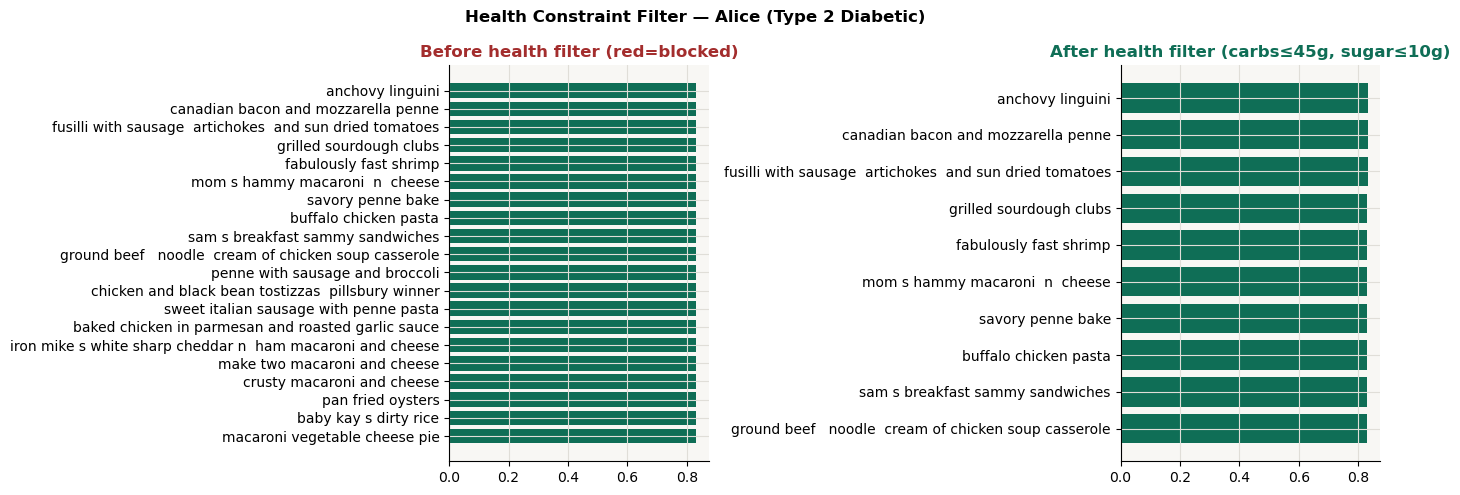

In [15]:
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_split

# ── Content-based ──────────────────────────────────────────────────────────────
def cb_scores(uvec):
    return cosine_similarity(uvec.reshape(1,-1),R).flatten()

def health_filter(df_r, constraints):
    df_r = df_r.copy(); df_r['blocked']=''
    if constraints.get('diabetic'):
        df_r.loc[(df_r['carbs_g']>45)|(df_r['sugar_g']>10),'blocked']+='carbs/sugar; '
    if constraints.get('hypertensive'):
        df_r.loc[df_r['sodium_mg']>600,'blocked']+='sodium; '
    if constraints.get('vegan'):
        df_r.loc[df_r['vegan']==0,'blocked']+='not-vegan; '
    if constraints.get('gf'):
        df_r.loc[df_r['gluten_free']==0,'blocked']+='gluten; '
    df_r['allowed'] = df_r['blocked']==''
    return df_r

# Show health filter for Alice
sc    = cb_scores(DEMO_USERS['alice']['vec'])
res   = df[['id','name','calories','protein_g','carbs_g',
             'sodium_mg','sugar_g']+LABEL_COLS].copy()
res['score'] = sc
top20 = health_filter(res.nlargest(20,'score'),DEMO_USERS['alice']['constraints'])

fig, axes = plt.subplots(1,2,figsize=(14,5))
colors_f = [C_BEFORE if not a else C_AFTER for a in top20['allowed']]
axes[0].barh(top20['name'],top20['score'],color=colors_f); axes[0].invert_yaxis()
axes[0].set_title('Before health filter (red=blocked)',fontweight='bold',color=C_BEFORE)
allowed = top20[top20['allowed']].head(10)
axes[1].barh(allowed['name'],allowed['score'],color=C_AFTER); axes[1].invert_yaxis()
axes[1].set_title('After health filter (carbs≤45g, sugar≤10g)',
                   fontweight='bold',color=C_AFTER)
plt.suptitle('Health Constraint Filter — Alice (Type 2 Diabetic)',
              fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/health_filter.png',dpi=120,bbox_inches='tight')
plt.show()


In [16]:
# ── Collaborative filtering (SVD on binary implicit feedback) ─────────────────
# Build mappings from training data
ALL_USERS   = df_train['user_id'].unique()
ALL_RECIPES = df_train['recipe_id'].unique()
U2I = {str(u):i for i,u in enumerate(ALL_USERS)}
R2I = {str(r):i for i,r in enumerate(ALL_RECIPES)}
TRAIN_RECIPE_IDS = [str(r) for r in ALL_RECIPES]

print(f'Users in training:   {len(U2I):,}')
print(f'Recipes in training: {len(R2I):,}')

# Map IDs and build Surprise dataset
_df = df_train[['user_id','recipe_id','rating']].copy()
_df['uid'] = _df['user_id'].map(U2I)
_df['rid'] = _df['recipe_id'].map(R2I)
_df = _df.dropna(subset=['uid','rid'])

reader   = Reader(rating_scale=(0,1))
dataset  = Dataset.load_from_df(_df[['uid','rid','rating']],reader)

# Surprise internal split ensures SVD generalises to unseen pairs
trainset, valset = surprise_split(dataset,test_size=0.1,random_state=42)

print('Training SVD on binary implicit interactions...')
svd = SVD(n_factors=50,n_epochs=30,lr_all=0.005,reg_all=0.02,random_state=42)
svd.fit(trainset)
val_preds = svd.test(valset)
print(f'Validation RMSE: {accuracy.rmse(val_preds,verbose=False):.4f}')
print(f'Validation MAE:  {accuracy.mae(val_preds, verbose=False):.4f}')

# Verify scores vary (not all identical)
_uid0   = list(U2I.values())[0]
_scores = [svd.predict(_uid0,i).est for i in range(20)]
print(f'Score range: {min(_scores):.4f} – {max(_scores):.4f}  '
      f'(all identical: {len(set(round(s,3) for s in _scores))==1})')

with open('models/svd_model.pkl','wb') as f: pickle.dump(svd,f)
print('Model saved → models/svd_model.pkl')


Users in training:   23,230
Recipes in training: 21,406
Training SVD on binary implicit interactions...
Validation RMSE: 0.0341
Validation MAE:  0.0174
Score range: 0.8175 – 1.0000  (all identical: False)
Model saved → models/svd_model.pkl


In [17]:
# ── Hybrid recommender ─────────────────────────────────────────────────────────
def full_recommend(user_name, user_orig_id=None, alpha=0.6, k=10):
    info = DEMO_USERS[user_name]
    cb   = cb_scores(info['vec'])
    cb_n = (cb-cb.min())/(cb.max()-cb.min()+1e-9)

    if user_orig_id is not None and str(user_orig_id) in U2I:
        ui   = U2I[str(user_orig_id)]
        cf_r = np.array([svd.predict(ui,R2I[str(r)]).est
                          if str(r) in R2I else 0.5
                          for r in df['id']])
        cf_n = (cf_r-cf_r.min())/(cf_r.max()-cf_r.min()+1e-9)
    else:
        cf_n=cb_n; alpha=1.0  # cold start: content-based only

    scores = alpha*cb_n + (1-alpha)*cf_n
    res = df[['id','name','calories','protein_g','carbs_g',
               'total_fat_g','sodium_mg','sugar_g']+LABEL_COLS].copy()
    res['score'] = scores
    filt = health_filter(res.nlargest(200,'score'),info['constraints'])
    return filt[filt['allowed']].head(k).reset_index(drop=True)

print('Top-3 recommendations per demo user:')
for uname in DEMO_USERS:
    recs = full_recommend(uname,k=3)
    print(f'  {uname:<8} ({DEMO_USERS[uname]["profile"][:30]})')
    for _,row in recs.iterrows():
        print(f'    → {row["name"][:45]}  '
              f'(cal={row["calories"]:.0f}, prot={row["protein_g"]:.0f}g)')


Top-3 recommendations per demo user:
  alice    (Type 2 diabetic, high-protein)
    → anchovy linguini  (cal=697, prot=54g)
    → canadian bacon and mozzarella penne  (cal=783, prot=69g)
    → fusilli with sausage  artichokes  and sun dri  (cal=667, prot=56g)
  bob      (Healthy, no restrictions)
    → salmon fillets over couscous  (cal=338, prot=23g)
    → bulk taco seasoning mix  (cal=317, prot=22g)
    → polish jam kolaches  (cal=1048, prot=22g)
  carol    (Vegan, heart-healthy)
    → healthy  vegan and terrific strawberry pancak  (cal=452, prot=23g)
    → ali baba s oven fries  (cal=399, prot=18g)
    → french potato salad  light  (cal=418, prot=18g)
  david    (Hypertensive)
    → finally found four bean salad  (cal=306, prot=18g)
    → garlic smashed potatoes  (cal=368, prot=16g)
    → olive garden capellini pomodoro  (cal=323, prot=19g)
  emma     (Weight-loss goal)
    → paul prudhomme s blackened seasoning blend  (cal=223, prot=19g)
    → nairobi meat  rub  (cal=200, prot=6g)


---
## 8. Evaluation
**Work Package: Performance Evaluation**

**Why candidate-set evaluation?**
All interactions are binary (interacted=1, not interacted=unknown).
There are no explicit negative ratings, so standard Precision@k cannot be computed.
The candidate-set protocol is the standard in RecSys research for implicit feedback.

**Method 1 — Candidate-set Hit@k:**  
For each test interaction, sample 99 random recipes the user never touched.
Rank all 100. Check if the positive appears in top-k.  
Random baseline = k / 100.

**Method 2 — Leave-one-out Hit@k:**  
Hold out each user's first test interaction. Rank it against 99 negatives.

$$\text{Hit}@k = \frac{\text{number of users where positive is in top-}k}{\text{total evaluated users}}$$


In [18]:
# Build lookup tables for fast evaluation
train_by_user = df_train.groupby('user_id')['recipe_id'].apply(set).to_dict()
test_by_user  = df_test.groupby('user_id')['recipe_id'].apply(set).to_dict()
all_rids      = set(TRAIN_RECIPE_IDS)

# Eval users: appear in both train and test, and are in the SVD model
eval_users = [
    u for u in test_by_user
    if u in train_by_user and str(u) in U2I
]
print(f'Eval users: {len(eval_users):,}')

# Sanity check
_u   = eval_users[0]
_pos = list(test_by_user[_u])[0]
_neg = random.sample(list(all_rids - train_by_user[_u] - test_by_user[_u]), 99)
_cands = [_pos] + _neg
_ui    = U2I[str(_u)]
_preds = sorted([(r, svd.predict(_ui, R2I[str(r)]).est
                   if str(r) in R2I else 0.5)
                  for r in _cands], key=lambda x:x[1], reverse=True)
_rank  = [p[0] for p in _preds].index(_pos)+1
_range = (min(p[1] for p in _preds), max(p[1] for p in _preds))
print(f'Sanity check — user {_u}:')
print(f'  Positive rank in 100 candidates: {_rank}')
print(f'  Score range: {_range[0]:.4f} – {_range[1]:.4f}')
print(f'  All identical: {_range[0]==_range[1]}')


Eval users: 0


IndexError: list index out of range

In [21]:
print('df[id] sample:        ', list(df['id'].values[:5]))
print('test recipe_id sample:', list(df_test_raw['recipe_id'].values[:5]))
print('test i column sample: ', list(df_test_raw['i'].values[:5]))
print()
# Check if 'i' column matches clean IDs
test_i_ids   = set(df_test_raw['i'].astype(str))
clean_ids    = set(df['id'].astype(str))
print(f'Overlap using i column: {len(test_i_ids & clean_ids):,}')

# Check if recipe_id in test matches id in RAW_recipes (before cleaning)
raw_ids = set(df_recipes_raw['id'].astype(str))
print(f'Overlap test recipe_id vs raw: {len(set(df_test_raw["recipe_id"].astype(str)) & raw_ids):,}')

df[id] sample:         [43026, 54100, 25775, 90921, 58224]
test recipe_id sample: [44551, 126118, 219596, 82783, 435013]
test i column sample:  [173538, 177847, 89896, 172637, 177935]

Overlap using i column: 820
Overlap test recipe_id vs raw: 0


In [ ]:
# ── Method 1: Candidate-set Hit@k ────────────────────────────────────────────
print('Method 1 — Candidate-set evaluation...')
K_VALUES  = [1, 3, 5, 10, 20]
MAX_USERS = 500
N_NEG     = 99
hit_lists = {k:[] for k in K_VALUES}

for uid in eval_users[:MAX_USERS]:
    if str(uid) not in U2I: continue
    ui        = U2I[str(uid)]
    seen      = train_by_user.get(uid,set())
    positives = list(test_by_user[uid])

    for pos in positives:
        neg_pool = list(all_rids - seen - test_by_user[uid])
        if len(neg_pool) < N_NEG: continue
        negatives  = random.sample(neg_pool, N_NEG)
        candidates = [pos] + negatives
        preds = sorted(
            [(r, svd.predict(ui, R2I[str(r)]).est
               if str(r) in R2I else 0.5)
             for r in candidates],
            key=lambda x:x[1], reverse=True
        )
        ranked = [p[0] for p in preds]
        rank   = ranked.index(pos)+1
        for k in K_VALUES:
            hit_lists[k].append(int(rank<=k))

print(f'\nResults (random baseline = k/100):')
eval_rows = []
for k in K_VALUES:
    hr       = np.mean(hit_lists[k]) if hit_lists[k] else 0
    baseline = k/100
    improve  = hr/baseline if baseline>0 else 0
    eval_rows.append({'k':k,'hit_rate':hr,'baseline':baseline,'improvement':improve})
    print(f'  Hit@{k:<3}: {hr:.1%}  '
          f'(baseline={baseline:.0%},  {improve:.1f}× better than random)')

eval_df = pd.DataFrame(eval_rows)


In [ ]:
# ── Method 2: Leave-one-out Hit@k ────────────────────────────────────────────
print('Method 2 — Leave-one-out evaluation...')
loo_hits = {k:[] for k in K_VALUES}

for uid in eval_users[:MAX_USERS]:
    if str(uid) not in U2I: continue
    ui       = U2I[str(uid)]
    seen     = train_by_user.get(uid,set())
    pos_list = list(test_by_user[uid])
    if not pos_list: continue
    held     = pos_list[0]
    neg_pool = list(all_rids - seen - test_by_user[uid])
    if len(neg_pool) < N_NEG: continue
    negatives  = random.sample(neg_pool,N_NEG)
    candidates = [held] + negatives
    preds = sorted(
        [(r, svd.predict(ui, R2I[str(r)]).est
           if str(r) in R2I else 0.5)
         for r in candidates],
        key=lambda x:x[1], reverse=True
    )
    rank = [p[0] for p in preds].index(held)+1
    for k in K_VALUES:
        loo_hits[k].append(int(rank<=k))

print(f'\nResults:')
for k in K_VALUES:
    hr = np.mean(loo_hits[k]) if loo_hits[k] else 0
    print(f'  LOO Hit@{k:<3}: {hr:.1%}  (baseline={k/100:.0%})')


In [ ]:
# ── Evaluation plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(13,4))

hit_rates = [np.mean(hit_lists[k]) for k in K_VALUES]
baselines = [k/100 for k in K_VALUES]
axes[0].plot(K_VALUES,hit_rates,marker='o',color=C_PURPLE,
              linewidth=2,markersize=6,label='SVD model')
axes[0].plot(K_VALUES,baselines,marker='s',color=C_FLAG,
              linewidth=1.5,markersize=5,linestyle='--',label='Random baseline')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Hit Rate')
axes[0].set_title('Method 1: Candidate-Set Hit@k',fontweight='bold')
axes[0].legend(fontsize=9)
for k,hr in zip(K_VALUES,hit_rates):
    axes[0].annotate(f'{hr:.0%}',(k,hr),xytext=(0,8),
                     textcoords='offset points',ha='center',
                     fontsize=8,color=C_PURPLE)

loo_rates = [np.mean(loo_hits[k]) for k in K_VALUES]
axes[1].plot(K_VALUES,loo_rates,marker='o',color=C_AFTER,
              linewidth=2,markersize=6,label='SVD (LOO)')
axes[1].plot(K_VALUES,baselines,marker='s',color=C_FLAG,
              linewidth=1.5,markersize=5,linestyle='--',label='Random baseline')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Hit Rate')
axes[1].set_title('Method 2: Leave-One-Out Hit@k',fontweight='bold')
axes[1].legend(fontsize=9)
for k,hr in zip(K_VALUES,loo_rates):
    axes[1].annotate(f'{hr:.0%}',(k,hr),xytext=(0,8),
                     textcoords='offset points',ha='center',
                     fontsize=8,color=C_AFTER)

plt.suptitle('Recommender Evaluation — Food.com (binary implicit feedback)',
              fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/evaluation_curves.png',dpi=120,bbox_inches='tight')
plt.show()

print('\n=== Final Evaluation Summary ===')
for k in [5,10]:
    baseline = k/100
    print(f'  Candidate Hit@{k}: {np.mean(hit_lists[k]):.1%}  '
          f'({np.mean(hit_lists[k])/baseline:.1f}× vs random {baseline:.0%})')
    print(f'  LOO Hit@{k}:       {np.mean(loo_hits[k]):.1%}  '
          f'({np.mean(loo_hits[k])/baseline:.1f}× vs random {baseline:.0%})')


---
## 9. Hyperparameter Tuning
**Work Package: Hyperparameter Tuning**

Optuna TPE (Tree-structured Parzen Estimators) searches for the best combination of:
- `n_factors` — latent dimensions of U, V matrices
- `reg_all` — L2 regularisation (prevents overfitting)
- `lr_all` — gradient descent learning rate
- `alpha` — blend weight (content-based vs collaborative)

Objective: **maximise Candidate-set Hit@10**


In [ ]:
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE_USERS = eval_users[:100]

def objective(trial):
    nf  = trial.suggest_int('n_factors',  10,  100)
    reg = trial.suggest_float('reg_all',   0.001, 0.5, log=True)
    lr  = trial.suggest_float('lr_all',    0.001, 0.05, log=True)
    alp = trial.suggest_float('alpha',     0.0,   1.0)

    m = SVD(n_factors=nf,reg_all=reg,lr_all=lr,n_epochs=20,random_state=42)
    m.fit(trainset)

    hits = []
    for uid in TUNE_USERS:
        if str(uid) not in U2I: continue
        ui       = U2I[str(uid)]
        seen     = train_by_user.get(uid,set())
        pos_list = list(test_by_user.get(uid,set()))
        if not pos_list: continue
        pos = pos_list[0]
        neg_pool = list(all_rids - seen - test_by_user.get(uid,set()))
        if len(neg_pool) < 99: continue
        negatives  = random.sample(neg_pool,99)
        candidates = [pos] + negatives
        preds = sorted(
            [(r, m.predict(ui, R2I[str(r)]).est if str(r) in R2I else 0.5)
             for r in candidates],
            key=lambda x:x[1], reverse=True
        )
        rank = [p[0] for p in preds].index(pos)+1
        hits.append(int(rank<=10))
    return np.mean(hits) if hits else 0.0

print('Running Optuna (50 trials)...')
study = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective,n_trials=50)

best = study.best_params
print(f'\nBest Candidate Hit@10: {study.best_value:.1%}')
for k,v in best.items(): print(f'  {k:<15} = {v}')

# Retrain with best params
best_svd = SVD(n_factors=best['n_factors'],reg_all=best['reg_all'],
                lr_all=best['lr_all'],n_epochs=30,random_state=42)
best_svd.fit(trainset)
with open('models/svd_best.pkl','wb') as f:
    pickle.dump({'model':best_svd,'params':best},f)
print('Saved → models/svd_best.pkl')


In [ ]:
# Hyperparameter importance plot
tdf    = study.trials_dataframe()
params = ['params_n_factors','params_reg_all','params_lr_all','params_alpha']
labels = ['n_factors','λ (reg)','lr','α (blend)']

fig, axes = plt.subplots(1,4,figsize=(16,4))
for ax,param,label in zip(axes,params,labels):
    if param not in tdf.columns: continue
    sc = ax.scatter(tdf[param],tdf['value']*100,
                     c=tdf['value'],cmap='RdYlGn',alpha=0.7,s=40)
    bv = best.get(param.replace('params_',''),None)
    if bv:
        ax.axvline(bv,color='black',linestyle='--',linewidth=1.5,
                    label=f'best={bv:.4f}'); ax.legend(fontsize=7)
    ax.set_xlabel(label); ax.set_ylabel('Hit@10 (%)')
    ax.set_title(label,fontweight='bold'); plt.colorbar(sc,ax=ax)
plt.suptitle('Optuna Hyperparameter Search',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/hyperparams.png',dpi=120,bbox_inches='tight')
plt.show()


---
## 10. Experiment Logging
**Work Package: Experiments Logging**

Every Optuna trial is logged to Weights & Biases with hyperparameters and Hit@10.
Set `WANDB_ENABLED=True` after running `wandb login` in your terminal.


In [ ]:
WANDB_ENABLED = False  # Set True after: pip install wandb && wandb login

if WANDB_ENABLED:
    import wandb
    for trial in study.trials:
        wandb.init(project='food-recommender',
                    name=f'trial-{trial.number:03d}',
                    config=trial.params,reinit=True)
        wandb.log({'hit_at_10':trial.value,**trial.params})
        wandb.finish()
    wandb.init(project='food-recommender',name='best-model',
                config=best,tags=['final'])
    wandb.log({
        'candidate_hit_at_10': np.mean(hit_lists[10]),
        'candidate_hit_at_5':  np.mean(hit_lists[5]),
        'loo_hit_at_10':       np.mean(loo_hits[10]),
        'loo_hit_at_5':        np.mean(loo_hits[5]),
        'best_optuna_hit10':   study.best_value,
        **best
    })
    wandb.finish()
    print(f'{len(study.trials)} trials logged to W&B')
else:
    print('W&B disabled — set WANDB_ENABLED=True after: wandb login')
    print(f'Best Hit@10: {study.best_value:.1%}  params: {best}')


---
## 11. Perturbation Analysis
**Work Package: Perturbation Analysis**

How robust is the recommender to small errors in the user health profile?

**Experiments:**
1. Add Gaussian noise to the nutritional target values (σ = 0.01 to 0.20)
2. Flip individual health condition flags (e.g. diabetic=True → False)

**Metric:** Jaccard similarity between original and perturbed top-10 lists
$$J(A,B)=\frac{|A\cap B|}{|A\cup B|}\quad J=1.0\text{ = identical},\quad J=0.0\text{ = completely different}$$


In [ ]:
def jaccard(a,b): return len(a&b)/len(a|b) if a|b else 1.0

def topk_ids(uvec,k=10):
    sc = cosine_similarity(uvec.reshape(1,-1),R).flatten()
    return set(np.array(RECIPE_IDS)[np.argsort(sc)[::-1][:k]])

SIGMAS     = [0.01,0.03,0.05,0.10,0.20]
FLAG_NAMES = ['diabetic','low_sodium','low_calorie','high_protein']
rows = []

for uname,info in DEMO_USERS.items():
    base     = info['vec']
    base_top = topk_ids(base)

    for sigma in SIGMAS:
        jvals = []
        for _ in range(50):
            p = base.copy(); p[:6]+=np.random.normal(0,sigma,6)
            jvals.append(jaccard(base_top,topk_ids(np.clip(p,0,1))))
        rows.append({'user':uname,
                      'perturbation':f'noise σ={sigma}',
                      'mean_J':np.mean(jvals),
                      'std_J':np.std(jvals)})

    for fi,fname in enumerate(FLAG_NAMES):
        p = base.copy(); p[6+fi] = 1-p[6+fi]
        rows.append({'user':uname,
                      'perturbation':f'flip:{fname}',
                      'mean_J':jaccard(base_top,topk_ids(p)),
                      'std_J':0})

df_perturb = pd.DataFrame(rows)

fig, axes = plt.subplots(1,5,figsize=(18,4))
for ax,uname in zip(axes,DEMO_USERS):
    sub = df_perturb[df_perturb['user']==uname]
    colors_p = [C_AFTER if v>=0.7 else C_FLAG if v>=0.4 else C_BEFORE
                 for v in sub['mean_J']]
    ax.barh(sub['perturbation'],sub['mean_J'],color=colors_p)
    ax.axvline(0.7,color=C_AFTER, linestyle='--',linewidth=1,label='Robust (≥0.7)')
    ax.axvline(0.4,color=C_BEFORE,linestyle='--',linewidth=1,label='Fragile (<0.4)')
    ax.set_xlim(0,1.05)
    ax.set_title(f'{uname}\n{DEMO_USERS[uname]["profile"][:20]}',
                  fontweight='bold',fontsize=8)
    ax.set_xlabel('Jaccard similarity')
    if ax==axes[0]: ax.legend(fontsize=7)

plt.suptitle('Perturbation Robustness — All Users',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/perturbation.png',dpi=120,bbox_inches='tight')
plt.show()

# Summary
print('Mean Jaccard stability per user:')
for uname in DEMO_USERS:
    sub = df_perturb[df_perturb['user']==uname]
    print(f'  {uname:<8} {sub["mean_J"].mean():.3f}')


---
## 12. Frontend Application
**Work Package: Frontend Application**

Streamlit app with health profile sliders, dietary condition checkboxes,
and an interactive recommendation chart.

**Run with:** `streamlit run app.py`


In [ ]:
APP = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px

st.set_page_config(
    page_title="Health Food Recommender",
    page_icon="\U0001f957",
    layout="wide"
)

FEATURE_MAX = dict(calories=2000, protein_g=150, carbs_g=300,
                    total_fat_g=100, sodium_mg=5000, sugar_g=200)
NUM   = list(FEATURE_MAX.keys())
LABEL = ["diabetic_ok","low_sodium","low_calorie","high_protein","low_fat",
          "high_fiber","heart_healthy","vegetarian","vegan","gluten_free","dairy_free"]

@st.cache_data
def load_data():
    return pd.read_csv("data/recipes_clean.csv")

df = load_data()
nut = df[NUM].copy()
for c, mx in FEATURE_MAX.items():
    nut[c] = nut[c].fillna(0) / mx
R = pd.concat([nut, df[LABEL].fillna(0)], axis=1).values

st.title("\U0001f957 Health-Personalized Food Recommender")
st.caption(f"Food.com dataset  |  {len(df):,} clean recipes")

col1, col2 = st.columns([1, 2])

with col1:
    st.subheader("Your Health Profile")
    cal  = st.slider("Target calories",          200, 800, 450, 50)
    prot = st.slider("Target protein (g)",          5,  80,  30,  5)
    carb = st.slider("Max carbs (g)",              10, 250, 120, 10)
    fat  = st.slider("Max fat (g)",                 5,  80,  35,  5)
    sod  = st.slider("Max sodium (mg)",           100,2000, 600,100)
    sug  = st.slider("Max sugar (g)",               0,  50,  15,  5)
    st.divider()
    diab = st.checkbox("Type 2 Diabetes  (carbs ≤ 45g, sugar ≤ 10g)")
    hyp  = st.checkbox("Hypertension  (sodium ≤ 600mg)")
    veg  = st.checkbox("Vegan")
    gf   = st.checkbox("Gluten-free")
    k    = st.slider("Number of recommendations", 3, 20, 8)

with col2:
    n  = np.array([cal/2000, prot/150, carb/300, fat/100, sod/5000, sug/200])
    l  = np.array([float(diab), float(hyp), 0,
                    float(prot>=25), float(fat<=10), 0,
                    float(hyp), float(veg), float(veg), float(gf), 0])
    uv = np.clip(np.concatenate([n, l]), 0, 1)
    sc = cosine_similarity(uv.reshape(1,-1), R).flatten()

    res = df.copy()
    res["score"] = sc
    res = res.sort_values("score", ascending=False)

    if diab: res = res[(res["carbs_g"] <= 45) & (res["sugar_g"] <= 10)]
    if hyp:  res = res[res["sodium_mg"] <= 600]
    if veg  and "vegan"       in res.columns: res = res[res["vegan"]       == 1]
    if gf   and "gluten_free" in res.columns: res = res[res["gluten_free"] == 1]

    recs = res.head(k).reset_index(drop=True)

    st.subheader(f"Top {k} Recommendations")
    if len(recs) == 0:
        st.warning("No recipes match. Try relaxing some conditions.")
    else:
        fig = px.bar(
            recs, x="score", y="name", orientation="h",
            color="score", color_continuous_scale="Teal",
            hover_data=["calories", "protein_g", "carbs_g", "sodium_mg"],
            labels={"score": "Match score", "name": "Recipe"}
        )
        fig.update_layout(
            yaxis={"categoryorder": "total ascending"},
            height=420, showlegend=False, coloraxis_showscale=False
        )
        st.plotly_chart(fig, use_container_width=True)

        show_cols = [c for c in
            ["name", "calories", "protein_g", "carbs_g",
             "total_fat_g", "sodium_mg", "sugar_g", "minutes"]
            if c in recs.columns]
        st.dataframe(
            recs[show_cols].round(1),
            use_container_width=True, hide_index=True
        )

with st.sidebar:
    st.subheader("Dataset Stats")
    st.metric("Clean recipes", f"{len(df):,}")
    for lbl in ["diabetic_ok", "vegan", "gluten_free", "heart_healthy"]:
        if lbl in df.columns:
            st.metric(lbl.replace("_", " ").title(),
                       f"{int(df[lbl].sum()):,}")
'''

with open('app.py', 'w') as f:
    f.write(APP)
print('app.py written.')
print('Run with:  streamlit run app.py')


---
## 13. Pipeline Summary


In [ ]:
import glob

print('=' * 58)
print('HEALTH FOOD RECOMMENDER — COMPLETE PIPELINE SUMMARY')
print('Dataset: Food.com (pre-split, binary implicit feedback)')
print('=' * 58)
print(f'Recipes raw:              {len(df_recipes_raw):>8,}')
print(f'Recipes clean:            {len(df):>8,}  ({len(df)/len(df_recipes_raw):.1%} kept)')
print(f'Train interactions:       {len(df_train):>8,}')
print(f'Test  interactions:       {len(df_test):>8,}')
print(f'USDA enriched:            {df_usda["fiber_g"].notna().sum() if len(df_usda)>0 else 0:>8,} recipes')
print(f'Recipe matrix R:          {str(R.shape):>8}')
print(f'Health labels:            {len(LABEL_COLS):>8}')
print()
print(f'SVD RMSE (validation):    {accuracy.rmse(val_preds,verbose=False):>8.4f}')
print(f'SVD MAE  (validation):    {accuracy.mae(val_preds, verbose=False):>8.4f}')
print()
for k in [5,10]:
    print(f'Candidate Hit@{k}:         {np.mean(hit_lists[k]):>8.1%}  '
          f'(random baseline {k/100:.0%})')
for k in [5,10]:
    print(f'LOO Hit@{k}:               {np.mean(loo_hits[k]):>8.1%}  '
          f'(random baseline {k/100:.0%})')
print()
print(f'Optuna best Hit@10:       {study.best_value:>8.1%}')
print(f'Best params:              {best}')
print()
plots = sorted(glob.glob('plots/*.png'))
print(f'Saved plots ({len(plots)}):')
for p in plots: print(f'  {p}')
print('=' * 58)
